# MOST yearly journal trends

This notebook uses the same analysis subset as `stats_figures.ipynb`: quantitative research articles with complete availability coding (N=10,480). It summarizes public code and data availability by year within each journal.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
DATA_PATH = ROOT / "data" / "fla_cleaned.csv"
EXPECTED_ANALYSIS_N = 10480
FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Palatino Linotype", "Book Antiqua", "Palatino", "Times New Roman"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d8d1c8",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

DATA_COLORS = {
    "available": "#2B7A9B",
    "cite": "#C98A3A",
    "both": "#4B8F55",
    "none": "#D8D1C8",
}
CODE_COLORS = {"yes": "#2B7A9B", "no": "#D8D1C8"}
JOURNAL_SHORT_NAMES = {
    "Transportation Research Part A: Policy and Practice": "TR-A",
    "Transportation Research Part B: Methodological": "TR-B",
    "Transportation Research Part C: Emerging Technologies": "TR-C",
    "Transportation Research Part D: Transport and Environment": "TR-D",
    "Transportation Research Part E: Logistics and Transportation Review": "TR-E",
    "Transportation Research Part F: Traffic Psychology and Behaviour": "TR-F",
    "Transportation Research Interdisciplinary Perspectives": "TRIP",
}

In [2]:
raw_df = pd.read_csv(DATA_PATH)

def boolish(series):
    return series.fillna(False).astype(str).str.strip().str.lower().isin(["true", "1", "yes", "y"])

required_availability_fields = [
    "is_code_publicly_available",
    "is_data_cited_or_linked",
    "is_data_repository_available",
]
complete_availability = raw_df[required_availability_fields].notna().all(axis=1)
complete_availability &= raw_df[required_availability_fields].astype(str).apply(lambda col: col.str.strip().ne("")).all(axis=1)
df = raw_df[boolish(raw_df["is_quantitative_study"]) & complete_availability].copy()
assert len(df) == EXPECTED_ANALYSIS_N, f"Expected {EXPECTED_ANALYSIS_N:,} rows, found {len(df):,}"

df["code_availability"] = boolish(df["is_code_publicly_available"]).map({True: "yes", False: "no"})
data_cited = boolish(df["is_data_cited_or_linked"])
data_repo = boolish(df["is_data_repository_available"])
df["data_availability"] = "none"
df.loc[data_repo & ~data_cited, "data_availability"] = "available"
df.loc[data_cited & ~data_repo, "data_availability"] = "cite"
df.loc[data_repo & data_cited, "data_availability"] = "both"

df["journal"] = df["journal"].fillna("Unknown").replace("", "Unknown")
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)
journal_order = df["journal"].value_counts().index.tolist()
df.shape, df["year"].min(), df["year"].max()

((10480, 36), np.int64(2019), np.int64(2024))

In [11]:
def summarize_yearly(df, group_col):
    total = df.groupby([group_col, "year"]).size().rename("n")
    code = pd.crosstab([df[group_col], df["year"]], df["code_availability"]).reindex(columns=["yes", "no"], fill_value=0)
    data = pd.crosstab([df[group_col], df["year"]], df["data_availability"]).reindex(columns=["available", "cite", "both", "none"], fill_value=0)
    out = pd.concat([total, code.add_prefix("code_"), data.add_prefix("data_")], axis=1).reset_index()
    out = out.rename(columns={group_col: "group"}).sort_values(["group", "year"]).reset_index(drop=True)
    for col in ["code_yes", "code_no", "data_available", "data_cite", "data_both", "data_none"]:
        out[f"{col}_pct"] = out[col] / out["n"] * 100
        out["data_repository_any"] = out["data_available"] + out["data_both"]
        out["data_repository_any_pct"] = out["data_repository_any"] / out["n"] * 100
        out["data_cite_or_link_any"] = out["data_cite"] + out["data_both"]
        out["data_cite_or_link_any_pct"] = out["data_cite_or_link_any"] / out["n"] * 100
    return out

journal_yearly = summarize_yearly(df, "journal")
journal_yearly.head()

,group,year,n,code_yes,code_no,data_available,data_cite,data_both,data_none,code_yes_pct,data_repository_any,data_repository_any_pct,data_cite_or_link_any,data_cite_or_link_any_pct,code_no_pct,data_available_pct,data_cite_pct,data_both_pct,data_none_pct
0,Transportation Research Interdisciplinary Pers...,2019,58,3,55,1,29,1,27,5.172414,2,3.448276,30,51.724138,94.827586,1.724138,50.000000,1.724138,46.551724
1,Transportation Research Interdisciplinary Pers...,2020,154,7,147,7,65,1,81,4.545455,8,5.194805,66,42.857143,95.454545,4.545455,42.207792,0.649351,52.597403
2,Transportation Research Interdisciplinary Pers...,2021,194,6,188,3,81,0,110,3.092784,3,1.546392,81,41.752577,96.907216,1.546392,41.752577,0.000000,56.701031
3,Transportation Research Interdisciplinary Pers...,2022,182,6,176,4,65,1,112,3.296703,5,2.747253,66,36.263736,96.703297,2.197802,35.714286,0.549451,61.538462
4,Transportation Research Interdisciplinary Pers...,2023,185,6,179,4,42,1,138,3.243243,5,2.702703,43,23.243243,96.756757,2.162162,22.702703,0.540541,74.594595


In [20]:
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "axes.titlesize": 20,
})

(<Figure size 850x850 with 1 Axes>,
 <Axes: xlabel='Year', ylabel='Share of articles with data in a repository (%)'>)

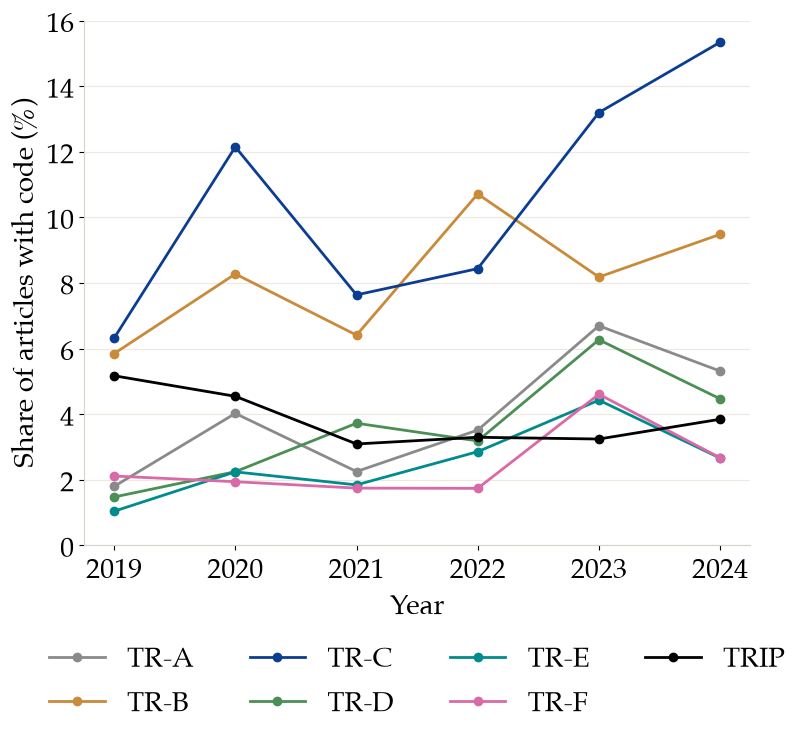

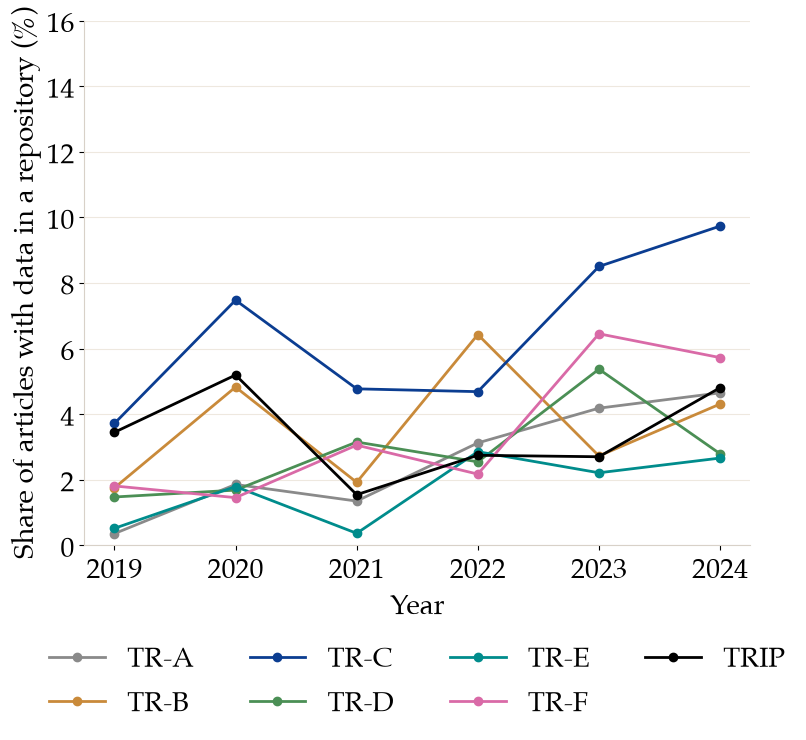

In [23]:
def display_journal(label):
    return JOURNAL_SHORT_NAMES.get(str(label), str(label))

journal_legend_order = [
    "Transportation Research Part A: Policy and Practice",
    "Transportation Research Part B: Methodological",
    "Transportation Research Part C: Emerging Technologies",
    "Transportation Research Part D: Transport and Environment",
    "Transportation Research Part E: Logistics and Transportation Review",
    "Transportation Research Part F: Traffic Psychology and Behaviour",
    "Transportation Research Interdisciplinary Perspectives",
]

JOURNAL_COLORS = {
    "Transportation Research Part A: Policy and Practice": "#8A8A8A",
    "Transportation Research Part B: Methodological": "#C98A3A",
    "Transportation Research Part C: Emerging Technologies": "#0B3D91",
    "Transportation Research Part D: Transport and Environment": "#4B8F55",
    "Transportation Research Part E: Logistics and Transportation Review": "#008C8C",
    "Transportation Research Part F: Traffic Psychology and Behaviour": "#D96AA7",
    "Transportation Research Interdisciplinary Perspectives": "#000000",
}


def plot_journal_trend(summary, value_col, ylabel, title, filename, ylim_max=20):
    fig, ax = plt.subplots(figsize=(8.5, 8.5))
    # make font size to be 20 here
    for journal in journal_legend_order:
        sub = summary[summary["group"] == journal].sort_values("year")
        if sub.empty:
            continue
        ax.plot(
            sub["year"],
            sub[value_col],
            marker="o",
            linewidth=2,
            label=display_journal(journal),
            color=JOURNAL_COLORS[journal],
        )

    # ax.set_title(title, fontsize=14)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, ylim_max)
    ax.set_xticks(sorted(summary["year"].unique().tolist()))
    ax.grid(axis="y", color="#eee8df", linewidth=0.8)
    ax.set_axisbelow(True)
    legend = ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    for text in legend.get_texts():
        text.set_color("black")
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    fig.savefig(FIG_DIR / f"{filename}.svg", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{filename}.pdf", dpi=300, bbox_inches="tight")
    return fig, ax

plot_journal_trend(
    journal_yearly,
    "code_yes_pct",
    "Share of articles with code (%)",
    "Public code availability by journal and year",
    "code_yes_by_journal_year",
    ylim_max=16,
)

plot_journal_trend(
    journal_yearly,
    "data_repository_any_pct",
    "Share of articles with data in a repository (%)",
    "Data repository availability by journal and year",
    "data_repository_by_journal_year",
    ylim_max=16,
)